<a href="https://colab.research.google.com/github/Changin7/ALURA--Desafio-1/blob/main/Desafio%201.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# 1. Enlaces originales de GitHub
enlace_1 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
enlace_2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
enlace_3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
enlace_4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"


df_sucursal_1 = pd.read_csv(enlace_1)
df_sucursal_2 = pd.read_csv(enlace_2)
df_sucursal_3 = pd.read_csv(enlace_3)
df_sucursal_4 = pd.read_csv(enlace_4)


coleccion_sucursales = [df_sucursal_1, df_sucursal_2, df_sucursal_3, df_sucursal_4]
nombres_etiquetas = ['Sucursal 1', 'Sucursal 2', 'Sucursal 3', 'Sucursal 4']


reporte_global = {}

print("=== REPORTE DE RENDIMIENTO ALURA STORE ===\n")

for indice, base_datos in enumerate(coleccion_sucursales):
    identificador = nombres_etiquetas[indice]

    # Métrica 1
    ingreso_neto = base_datos['Precio'].sum()

    # Métrica 2
    conteo_categorias = base_datos['Categoría del Producto'].value_counts()
    categoria_estrella = conteo_categorias.idxmax()

    # Métrica 3
    calif_media = base_datos['Calificación'].mean()

    # Métrica 4
    conteo_productos = base_datos['Producto'].value_counts()
    prod_top = conteo_productos.idxmax()
    prod_rezagado = conteo_productos.idxmin()

    # Métrica 5
    costo_envio_medio = base_datos['Costo de envío'].mean()


    reporte_global[identificador] = {
        'Ingreso': ingreso_neto,
        'Envio': costo_envio_medio,
        'Estrellas': calif_media
    }

    # Imprimir
    print(f"--- {identificador} ---")
    print(f"1. Facturación Total: ${ingreso_neto:,.2f}")
    print(f"2. Categoría Principal: {categoria_estrella} ({conteo_categorias.max()} ventas)")
    print(f"3. Satisfacción del Cliente: {calif_media:.2f} estrellas")
    print(f"4. Producto Más Vendido: {prod_top}")
    print(f"   Producto Menos Vendido: {prod_rezagado}")
    print(f"5. Tarifa Promedio de Envío: ${costo_envio_medio:,.2f}\n")

=== REPORTE DE RENDIMIENTO ALURA STORE ===

--- Sucursal 1 ---
1. Facturación Total: $1,150,880,400.00
2. Categoría Principal: Muebles (465 ventas)
3. Satisfacción del Cliente: 3.98 estrellas
4. Producto Más Vendido: Microondas
   Producto Menos Vendido: Auriculares con micrófono
5. Tarifa Promedio de Envío: $26,018.61

--- Sucursal 2 ---
1. Facturación Total: $1,116,343,500.00
2. Categoría Principal: Muebles (442 ventas)
3. Satisfacción del Cliente: 4.04 estrellas
4. Producto Más Vendido: Iniciando en programación
   Producto Menos Vendido: Juego de mesa
5. Tarifa Promedio de Envío: $25,216.24

--- Sucursal 3 ---
1. Facturación Total: $1,098,019,600.00
2. Categoría Principal: Muebles (499 ventas)
3. Satisfacción del Cliente: 4.05 estrellas
4. Producto Más Vendido: Kit de bancas
   Producto Menos Vendido: Bloques de construcción
5. Tarifa Promedio de Envío: $24,805.68

--- Sucursal 4 ---
1. Facturación Total: $1,038,375,700.00
2. Categoría Principal: Muebles (480 ventas)
3. Satisfacció

/tmp/ipykernel_272/2568978405.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sucursales_lista, y=ingresos_lista, palette="mako", ax=eje1)


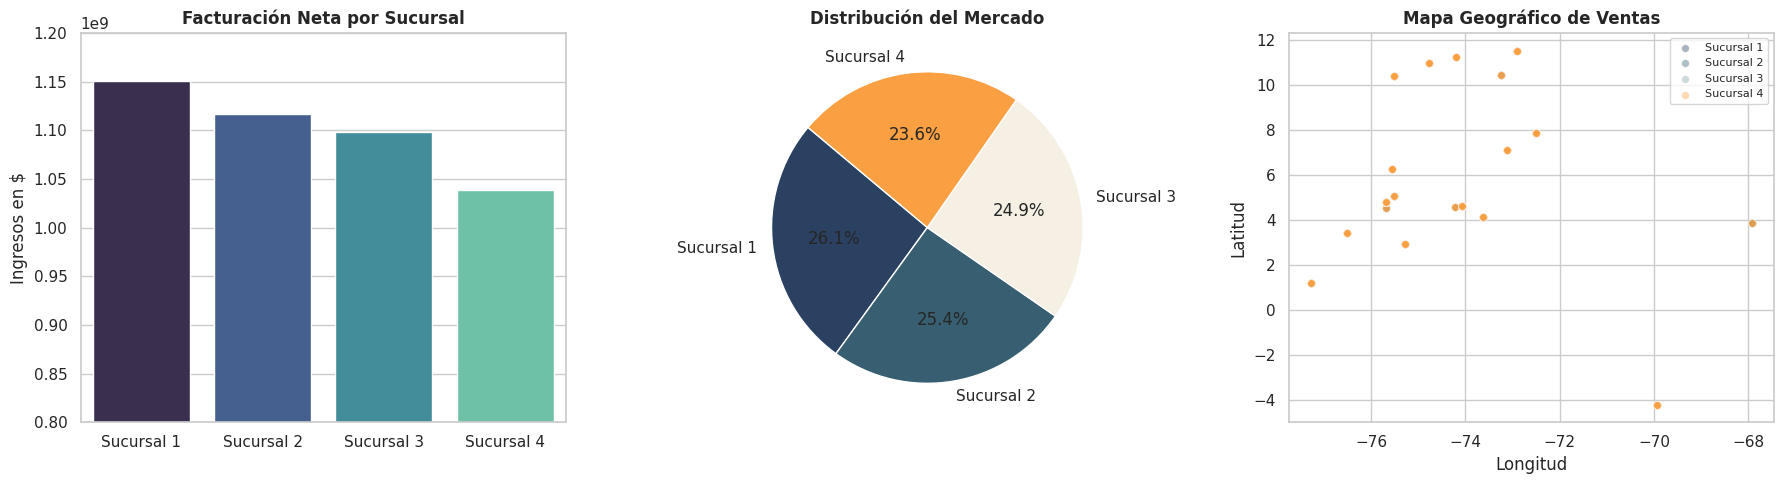

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns


sucursales_lista = list(reporte_global.keys())
ingresos_lista = [reporte_global[s]['Ingreso'] for s in sucursales_lista]
envios_lista = [reporte_global[s]['Envio'] for s in sucursales_lista]

sns.set_theme(style="whitegrid")
figura = plt.figure(figsize=(18, 5))

# GRÁFICO 1: Barras
eje1 = figura.add_subplot(1, 3, 1)
sns.barplot(x=sucursales_lista, y=ingresos_lista, palette="mako", ax=eje1)
eje1.set_title('Facturación Neta por Sucursal', fontweight='bold')
eje1.set_ylabel('Ingresos en $')
eje1.set_ylim(800000000, 1200000000)

# GRÁFICO 2: Pastel
eje2 = figura.add_subplot(1, 3, 2)
colores_pastel = ['#2b4162', '#385f71', '#f5f0e3', '#fa9f42']
eje2.pie(ingresos_lista, labels=sucursales_lista, autopct='%1.1f%%', startangle=140, colors=colores_pastel)
eje2.set_title('Distribución del Mercado', fontweight='bold')

# (Desafío Extra)
eje3 = figura.add_subplot(1, 3, 3)
sns.scatterplot(x='lon', y='lat', data=df_sucursal_1, color='#2b4162', alpha=0.4, label='Sucursal 1', s=30, ax=eje3)
sns.scatterplot(x='lon', y='lat', data=df_sucursal_2, color='#385f71', alpha=0.4, label='Sucursal 2', s=30, ax=eje3)
sns.scatterplot(x='lon', y='lat', data=df_sucursal_3, color='#89a7a7', alpha=0.4, label='Sucursal 3', s=30, ax=eje3)
sns.scatterplot(x='lon', y='lat', data=df_sucursal_4, color='#fa9f42', alpha=0.4, label='Sucursal 4', s=30, ax=eje3)
eje3.set_title('Mapa Geográfico de Ventas', fontweight='bold')
eje3.set_xlabel('Longitud')
eje3.set_ylabel('Latitud')
eje3.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()